In [2]:
# Importing all relevant libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# Loading dataset
df = pd.read_csv(r"C:\Amit Dubli\VS code\Assignment 4\data\q1_heart_disease.csv")

In [4]:
# Finding shape
print("Shape of dataset:", df.shape)

Shape of dataset: (800, 12)


In [5]:
# Finding data types
print("\nData Types:\n", df.dtypes)


Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object


In [6]:
# Finding missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [7]:
# Publishing first 5 rows
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


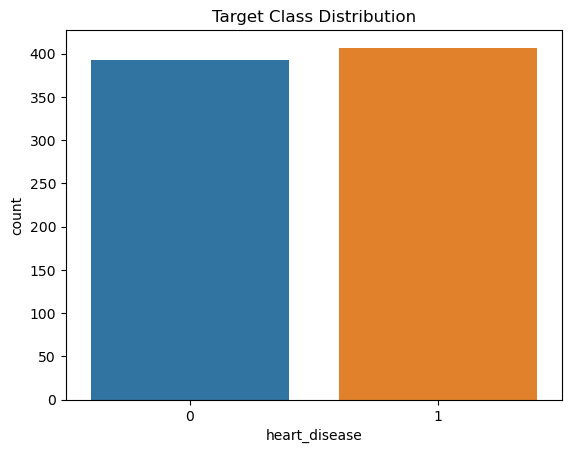

In [8]:
# Target distribution to find the imbalance between the two classes

plt.figure()
sns.countplot(x='heart_disease', data=df)
plt.title("Target Class Distribution")
plt.show()

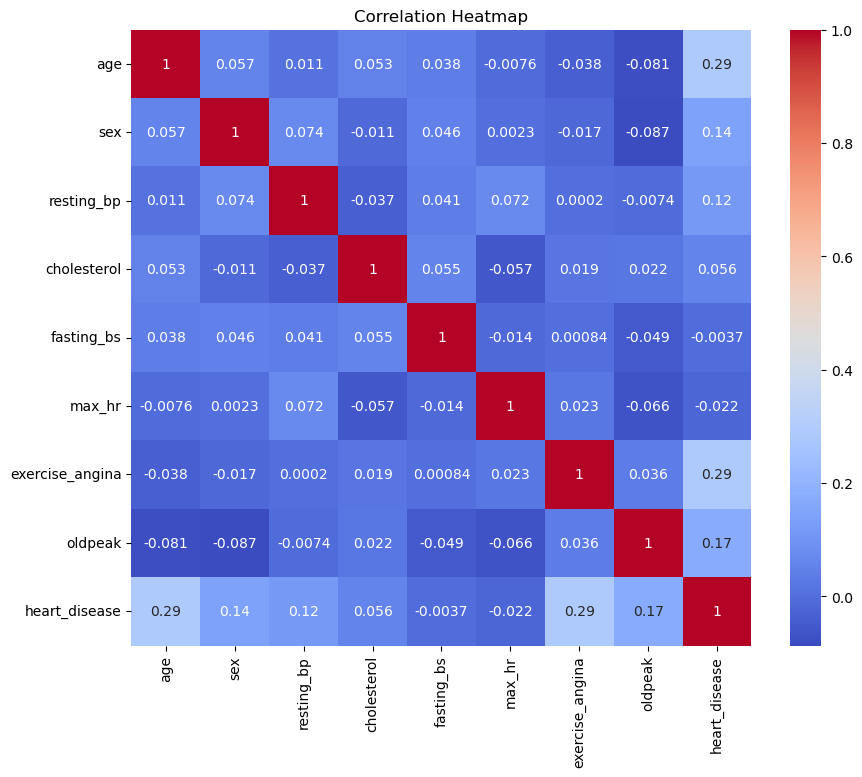

In [10]:
# Correlation heatmap will help us understand the relation between different features with each other

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

From the heat map we can say that age, excercise_angina, oldpeak,sex and resting_bp is corelated respectively majorly with heart_disease. 

In [11]:
# Separating features and target

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [12]:
# Identifing categorical & numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [13]:
# Handling missing values
for col in numerical_cols:
    X[col].fillna(X[col].median(), inplace=True)

for col in categorical_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

In [14]:
# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
# Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [8]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix:
 [[56 23]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
  

In [16]:
models = {
    "Decision Tree": dt,
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix:
 [[56 23]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



The Decision Tree model achieves an accuracy of 70%, with balanced performance across both classes. The precision and recall
values for both classes are around 0.70, indicating that the model performs similarly in detecting presence and absence of heart
disease.
However, the recall for class 1 (0.69) suggests that the model fails to identify about 31% of actual heart disease cases, 
which is a concern in medical applications where missing a positive case can be critical.
Overall, while the model shows moderate performance, improvements are needed, especially in recall for detecting heart disease.

In [17]:
models = {
    "Random Forest": rf,
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



The Random Forest model performs significantly better than the Decision Tree, achieving an accuracy of 79%. It shows strong
precision and recall values (~0.80) for both classes, indicating balanced performance.
Importantly, the recall for heart disease (0.81) is higher, meaning the model correctly identifies most patients with 
the disease and reduces false negatives compared to the Decision Tree.
Since minimizing missed disease cases is critical in medical applications, Random Forest is a more suitable and reliable model.

In [18]:
models = {
    "Gradient Boosting": gb
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



Among the three models, Random Forest performs the best with the highest accuracy (79%), F1-score (0.80), and recall (0.81) for detecting heart disease.
Although Gradient Boosting also performs well, it has slightly lower recall and misses more actual disease cases compared to Random Forest. Decision Tree performs the worst with the lowest accuracy and recall.
Since minimizing false negatives is critical in medical diagnosis, Random Forest is the most suitable model for this task.

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


GridSearchCV identified the optimal hyperparameters for the Random Forest model as n_estimators=100, max_depth=None, and min_samples_split=5.
This indicates that the best-performing model uses a sufficient number of trees to improve prediction accuracy, allows trees to grow fully to capture complex patterns, and applies a constraint on minimum samples required for splitting to reduce overfitting.
These tuned parameters help achieve better generalization and improved model performance compared to the default configuration.

In [20]:
# Evaluating the tuned model
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Tuned Model Performance:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Tuned Model Performance:
Confusion Matrix:
 [[57 22]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



After applying GridSearchCV, the tuned Random Forest model used the parameters n_estimators=100, max_depth=None, and min_samples_split=5.

However, the tuned model did not significantly improve performance compared to the baseline model. The accuracy decreased slightly from 0.79 to 0.77, and the F1-score also reduced marginally. The recall for detecting heart disease remained the same at 0.81, indicating no improvement in identifying positive cases.

This suggests that the original model was already well-optimized, and further tuning did not provide additional benefits on the test data. Therefore, the untuned Random Forest remains the preferred model.